In [1]:
from simphony.libraries import siepic
from ctypes import Array
import numpy as np, matplotlib.pyplot as plt
from pyparsing import Union
from simphony.circuit import Circuit
from simphony.simulation import SampleModeSimulation
from simphony.simulation.sample_mode import SampleModeSimulationParameters, SampleModeSimulation
from simphony.circuit.components import SampleModeComponent
from simphony.signals import SampleModeOpticalSignal
import jax
import jax.numpy as jnp
from scipy.integrate import solve_ivp
from functools import partial
from commpy.filters import rrcosfilter
from scipy.signal import upfirdn

In [2]:
weights_pos = [
(-1.8529+1.2004j), (-0.3196-2.2421j), (-0.0807+0.3613j), (0.3953-0.7351j),
(-0.6622+1.0805j), (1.2656-0.6759j), (-0.4257+0.5576j), (-1.4750-0.1723j),
(1.0845+0.1770j), (-0.9931-0.7891j), (1.3872-1.3912j), (0.5179-0.1975j),
(-0.3334+1.3283j), (0.2412-0.2970j), (1.2934+0.4172j), (-0.0285-0.3665j),
(0.1598+0.1360j), (-0.1339+0.0307j), (-0.0320-0.0561j), (0.0004-0.2796j)
]
weights_neg = [
(0.0143+0.1016j), (-0.0331+0.0775j), (-0.0939+0.0256j), (0.1447-0.1187j),
(-1.6501-0.6490j), (1.3570+1.0748j), (-0.9634+1.8448j), (-0.2971+0.0299j),
(-1.5362-1.5204j), (-1.1304+1.1892j), (0.4980-0.0418j), (1.5109+1.8817j),
(0.0244+0.1133j), (0.0733-0.0656j), (0.0814-0.0302j), (0.0344+0.1471j),
(0.0121+0.3212j), (-0.1494+0.0508j), (-0.0549-0.0148j), (-0.0784+0.1273j)
]
bias = 2.1396


data = np.load("green_machine_results_lorenz.npz", allow_pickle=True)["results"]
def unwrap_dict(x):
    
    if isinstance(x, dict):
        return x
    
    if isinstance(x, np.ndarray) and x.dtype == object:
        if x.ndim == 0:
            return x.item()          
        elif x.ndim == 1 and x.size == 1:
            return x[0]
    raise TypeError(f"Don't know how to unwrap type: {type(x)} (dtype={getattr(x,'dtype',None)})")

l = unwrap_dict(data)
print("top-level keys:", list(l.keys()))
keys = l.keys()
mask = []
for key in keys:
    if "in" in key:
        mask.append(key)
for key in mask:
    l.pop(key)
    
X = np.stack(
    [v["output"].amplitude[214::512, :, 0] for v in l.values()],
    axis=0
)
X = X.transpose(1, 2, 0)
print("X shape:", X.shape)
X =X.reshape(X.shape[0], int(X.shape[1]*X.shape[2]))
print("X reshaped shape:", X.shape)

sigma, rho, beta = 10.0, 28.0, 8/3
N = 10000
def lorenz(t, xyz):
    x, y, z = xyz
    return [sigma*(y - x), x*(rho - z) - y, x*y - beta*z]


dtt = 0.05
upsample = 1

T = dtt * (N - 1)

dt_fine = dtt / upsample
t_fine = np.arange(0.0, T + 1e-12, dt_fine)

sol_fine = solve_ivp(
    lorenz, (0.0, T), (0., 1., 1.05),
    method="RK45", max_step=dt_fine, t_eval=t_fine
)
x_f, y_f, z_f = sol_fine.y

def minmax(u):
    return (u - u.min())/(u.max() - u.min())
x_lorenz = minmax(x_f)
y_lorenz = minmax(y_f)
y       = minmax(z_f)
y_data = np.asarray(y, dtype=float)
X_data    = X
xpos, xneg = X[:,:20], X[:,20:45]
Y = np.abs(np.sum(xpos*weights_pos, axis =1 ))**2 - np.abs(np.sum(xneg*weights_neg, axis = 1))**2 + bias

T = 10.0e-11
dt = 1e-14
t = jnp.arange(0,T,dt)

top-level keys: ['out0', 'out4', 'out1', 'out5', 'out2', 'out6', 'out3', 'out7']
X shape: (10000, 5, 8)
X reshaped shape: (10000, 40)


In [3]:
class OpticalModulatorTime(SampleModeComponent):
    optical_ports = ["o0", "o1"]

    def __init__(self, *, length=1.0, operating_wl=1.55e-6, effective_index=2.4,
                 group_index=4.2, mod_signal=0.0):
        self.length = float(length)
        self.operating_wl = float(operating_wl)
        self.effective_index = float(effective_index)
        self.group_index = float(group_index)
        self.mod_signal = jnp.asarray(mod_signal)

    def sample_mode_initial_state(self, simulation_parameters):
        return jnp.int32(0)

    def sample_mode_step(self, inputs, state, simulation_parameters):
        a0 = inputs["o0"].amplitude  # forward field (W,M)
        a1 = inputs["o1"].amplitude  # reverse field (if any)
        lam = inputs["o0"].wavelength

        if a0.ndim == 1: a0 = a0[:, None]
        if a1.ndim == 1: a1 = a1[:, None]
        dtype = a0.dtype
        

        phase_t = self.mod_signal[state]
        

        coeff = jnp.exp(1j * (phase_t)).astype(dtype)
        out0 = SampleModeOpticalSignal(jnp.zeros_like(a1), lam)
        out1 = SampleModeOpticalSignal(a0 * coeff, lam)

        return {"o0": out0, "o1": out1}, state + 1

class StreamingCombSourceTime(SampleModeComponent):
    optical_ports = ["o0"]

    def __init__(self, base_wavelengths, scale=1.0):
        bw = jnp.asarray(base_wavelengths, jnp.float32).reshape(-1)
        self.base  = bw
        self.M     = int(bw.shape[0])
        self.scale = jnp.float32(scale)

    def sample_mode_initial_state(self, simulation_parameters):
        phi = jnp.zeros((self.M,), jnp.float32)
        t_idx = jnp.int32(0)
        return (phi, t_idx)

    @partial(jax.jit, static_argnums=(0,))
    def sample_mode_step(self, inputs, state, simulation_parameters):
        phi, t_idx = state
        A = (self.scale * jnp.exp(1j * phi).astype(jnp.complex64))[:, None]
        wls = self.base.astype(jnp.float32)
        out = {"o0": SampleModeOpticalSignal(amplitude=A, wavelength=wls)}
        return out, (phi, t_idx + jnp.int32(1))
    
class DataSourceTime(SampleModeComponent):
    """Two-port component that outputs preloaded complex amplitudes sample-by-sample."""

    optical_ports = ["o0", "o1"]

    def __init__(self, data_array, wavelengths):
        # Store precomputed data and wavelength grid
        self.data = jnp.asarray(data_array, dtype=jnp.complex64)
        self.T, self.M = self.data.shape
        self.wavelengths = jnp.asarray(wavelengths, dtype=jnp.float32)

    def sample_mode_initial_state(self, simulation_parameters):
        # Start at first sample
        return jnp.int32(0)

    @partial(jax.jit, static_argnums=(0,))
    def sample_mode_step(self, inputs, state, simulation_parameters):
        # Emit current sample, then increment time index
        t_idx = state
        sample = jnp.where(t_idx < self.T, self.data[t_idx], 0.0 + 0.0j)
        sample = sample.reshape(self.M, 1).astype(jnp.complex64)

        # Forward output carries data, reverse output is zero
        out_forward = SampleModeOpticalSignal(amplitude=sample, wavelength=self.wavelengths)
        out_reverse = SampleModeOpticalSignal(jnp.zeros_like(sample), self.wavelengths)

        return {"o0": out_reverse, "o1": out_forward}, t_idx + jnp.int32(1)

In [4]:
dt = 1e-14
t = jnp.arange(0, 100000)*dt
print(len(t))
netlist = {
    "instances":{
        # "hr1": "half_ring",
        # "hr2": "half_ring",
        "laser1" : "laser",
        "data_source": "data_source",
        "pm1": "phase_mod",
        "pm2": "phase_mod",
        "wg1":"waveguide",
        "wg2":"waveguide",
        "y1":"y_branch",
        "y2":"y_branch",
    },
    "connections":{
        # "hr1,port_3":"pm1,o0",
        # "hr2,port_3":"pm1,o1",
        # "hr1,port_1":"hr1,port_1",
        # "pm2,o0":"hr2,port_2",
        "laser1,o0":"data_source,o0",
        "data_source,o1":"y1,port_1",
        "y1,port_2":"wg1,o0",
        "wg1,o1":"pm1,o0",
        "pm1,o1":"y2,port_2",
        "y1,port_3":"wg2,o0",
        "wg2,o1":"y2,port_3",
        "y2,port_1":"pm2,o0",
        

    },
    "ports":{
        "in":"data_source,o1",
        # "out":"hr2,port_2",
        "out":"pm2,o1",
    }
}

models = {
    "laser": StreamingCombSourceTime,
    "phase_mod": OpticalModulatorTime,
    "waveguide":  siepic.waveguide,
    "half_ring": siepic.half_ring,
    "data_source": DataSourceTime,
    "y_branch": siepic.y_branch,
}
settings = {
    "laser1": {
    "base_wavelengths": jnp.array([1.52e-6,1.53e-6,1.54e-6,1.55e-6,1.56e-6], jnp.float32),
    "scale":jnp.sqrt(7.0),
    },
}
simulation_parameters = SampleModeSimulationParameters(
    optical_baseband_wavelengths=jnp.array([1.52e-6,1.53e-6,1.54e-6,1.55e-6,1.56e-6], jnp.float32),
    num_time_steps=int(len(t)), sampling_period=dt)

circuit = Circuit(netlist=netlist, models=models)
sim = SampleModeSimulation(circuit = circuit)
wavelengths=jnp.array([1.52e-6,1.53e-6,1.54e-6,1.55e-6,1.56e-6], jnp.float32)


100000


In [71]:
def generate_binary_phases(key, N):
    bits = jax.random.randint(key, (N,), 0, 2)
    return bits * jnp.pi, bits
def rrc_shape(symbols, h, sps):
    x = upfirdn(h.astype(np.float32), np.asarray(symbols, np.float32), up=sps)
    d = (len(h) - 1) // 2
    return jnp.asarray(x[d:d + len(symbols)*sps], dtype=jnp.float32)
sps = 512
beta = 0.35
span = 4
key_jax = jax.random.PRNGKey(0)
_, h = rrcosfilter(span*sps+1, beta, 1.0, sps)
phase_symbols, bits = generate_binary_phases(key_jax, 200)
phase_wave1 = rrc_shape(phase_symbols, h, sps)
phase_wave1 = np.asarray(phase_wave1, dtype=np.complex64)
wavelengths = np.array([1.52e-6, 1.53e-6, 1.54e-6, 1.55e-6, 1.56e-6], dtype=np.float32)

data_array = np.tile(phase_wave1[:, None], (1, len(wavelengths)))  # shape (T, 5)

settings["data_source"] = {
    "data_array": data_array,
    "wavelengths": wavelengths,
}

In [ ]:
input_data = np.stack(
    [v["output"].amplitude[:, :, 0] for v in l.values()],
    axis=0
)
input_data = input_data.transpose(1, 2, 0)
print(input_data.shape)
settings["data_source"] = {
    "data_array": jnp.array(input_data[:,0:5,0]),
    "wavelengths": wavelengths,
}

results = sim.run(simulation_parameters=simulation_parameters, settings=settings)


Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 28.23435139656067
Simulation time: 28.250 s


(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 7.689084529876709
Simulation time: 7.692 s
amplitude: 0.1968060489798839
phase: 2.5274641755856746


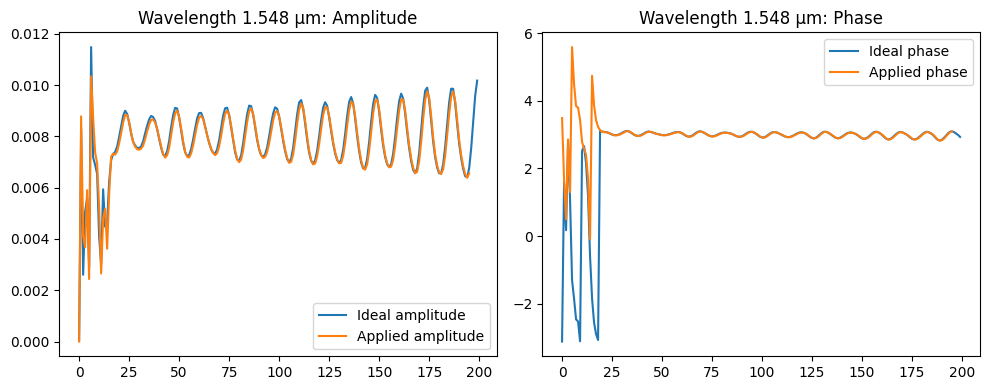

In [70]:
weight = weights_neg[1]
x_neg_current = X[:,21]
max_amp_neg = np.max(np.abs(weights_neg))
def phase_mod(amp):
            return 2 * np.arccos(amp)
        
x_neg_value = x_neg_current
input_data = np.stack(
    [v["output"].amplitude[:, :, 0] for v in l.values()],
    axis=0
)
input_data = input_data.transpose(1, 2, 0)
input_data = input_data.reshape(input_data.shape[0], int(input_data.shape[1]*input_data.shape[2]))
print(input_data.shape)

input_array = input_data[:len(t), 0 + 0*5 + 21]
settings["data_source"] = {
    "data_array": jnp.array(input_array[:,None]),
    "wavelengths": wavelengths,
}

phase_1 = phase_mod(np.abs(weight / (max_amp_neg + 1.0)))
phase_2 = -0.5 * phase_1 + np.angle(weight)

settings["pm1"] = {"mod_signal": phase_1 * jnp.ones_like(t)}
settings["pm2"] = {"mod_signal": phase_2 * jnp.ones_like(t)}

results = sim.run(simulation_parameters=simulation_parameters, settings=settings)

output = results["out"]["output"].amplitude[42::512, 0, 0]
out_np = np.asarray(output)

ref = x_neg_value[100]
desired_neg_amp = np.abs(ref * weight)
desired_neg_phase = np.angle(ref * weight)

amp_bias = float(desired_neg_amp / (np.abs(out_np[100] * (max_amp_neg+1.0))))
phase_bias = float(desired_neg_phase - np.angle(out_np[100]))

print("amplitude:", amp_bias)
print("phase:", phase_bias)

ideal_aligned = x_neg_value[:200] * weight

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title(f"Wavelength {w:.3f} μm: Amplitude")
plt.plot(np.abs(ideal_aligned), label='Ideal amplitude')
plt.plot(np.abs((out_np * (max_amp_neg+1.0)) * amp_bias), label='Applied amplitude')
plt.legend()

plt.subplot(1, 2, 2)
plt.title(f"Wavelength {w:.3f} μm: Phase")
plt.plot(np.angle(ideal_aligned), label='Ideal phase')
plt.plot(np.angle(out_np) + phase_bias, label='Applied phase')
plt.legend()
plt.tight_layout()
plt.show()

Found better alignment at index: 50 with error: 0.002504684607342751
Found better alignment at index: 53 with error: 0.0024921701916824795
Found better alignment at index: 54 with error: 0.002148293569894455
Found better alignment at index: 55 with error: 0.0020467284217307044
Found better alignment at index: 74 with error: 0.0020449654042171057
Best alignment at index: 74
amplitude: 0.19927966347722248
phase: 2.5260702217790474


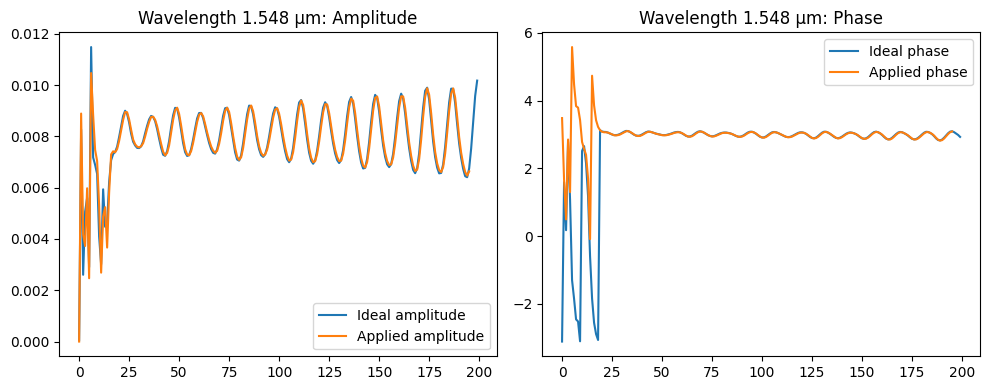

In [72]:
output = results["out"]["output"].amplitude[42::512, 0, 0]
out_np = np.asarray(output)
error = 1000
error_check = 1000
best_alignment = 49
while best_alignment < 150:
    best_alignment += 1
    ref = x_neg_value[best_alignment]
    desired_neg_amp = np.abs(ref * weight)
    desired_neg_phase = np.angle(ref * weight)

    amp_bias = float(desired_neg_amp / (np.abs(out_np[best_alignment] * (max_amp_neg+1.0))))
    phase_bias = float(desired_neg_phase - np.angle(out_np[best_alignment]))
    error = np.linalg.norm(
        (np.abs((out_np[50:] * (max_amp_neg+1.0)) * amp_bias) - np.abs(ideal_aligned)[50:len(out_np)])
    )
    if error < error_check:
        print("Found better alignment at index:", best_alignment, "with error:", error)
        error_check = error
        final_amp_bias = amp_bias
        final_phase_bias = phase_bias
        final_alignment = best_alignment


print("Best alignment at index:", final_alignment)
print("amplitude:", final_amp_bias)
print("phase:", final_phase_bias)

ideal_aligned = x_neg_value[:200] * weight

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title(f"Wavelength {w:.3f} μm: Amplitude")
plt.plot(np.abs(ideal_aligned), label='Ideal amplitude')
plt.plot(np.abs((out_np * (max_amp_neg+1.0)) * final_amp_bias), label='Applied amplitude')
plt.legend()

plt.subplot(1, 2, 2)
plt.title(f"Wavelength {w:.3f} μm: Phase")
plt.plot(np.angle(ideal_aligned), label='Ideal phase')
plt.plot(np.angle(out_np) + final_phase_bias, label='Applied phase')
plt.legend()
plt.tight_layout()
plt.show()



pos_bias:

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 9.210926532745361
Simulation time: 9.215 s
Found better alignment at index: 50 with error: 0.05614290768717879
Found better alignment at index: 56 with error: 0.05605178635651446
Found better alignment at index: 62 with error: 0.05505680673695511
Found better alignment at index: 68 with error: 0.055047212598270216
Found better alignment at index: 118 with error: 0.05504671211180948
Best alignment at index: 118
amplitude: 0.20854695972206888
phase: 2.480035247974951


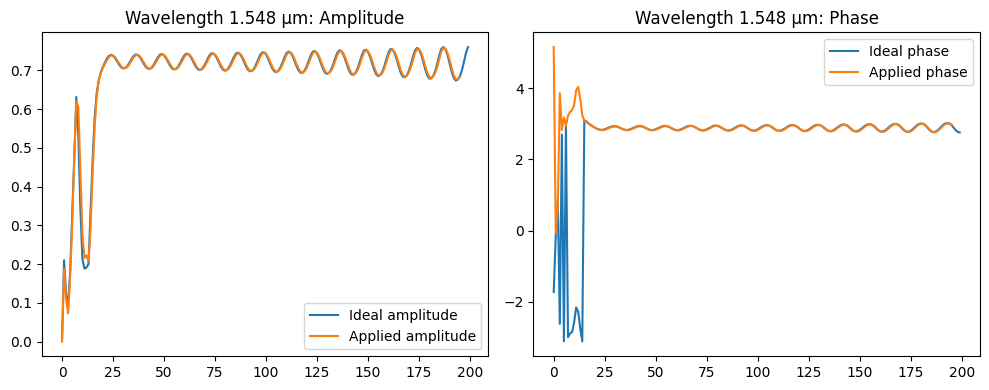

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 9.235899686813354
Simulation time: 9.240 s
Found better alignment at index: 50 with error: 0.034041268155993565
Found better alignment at index: 51 with error: 0.03154031478191009
Found better alignment at index: 52 with error: 0.026392874435363953
Found better alignment at index: 53 with error: 0.02426325584823171
Found better alignment at index: 85 with error: 0.024262860210684124
Best alignment at index: 85
amplitude: 0.20819002165699885
phase: -3.8016783681036106


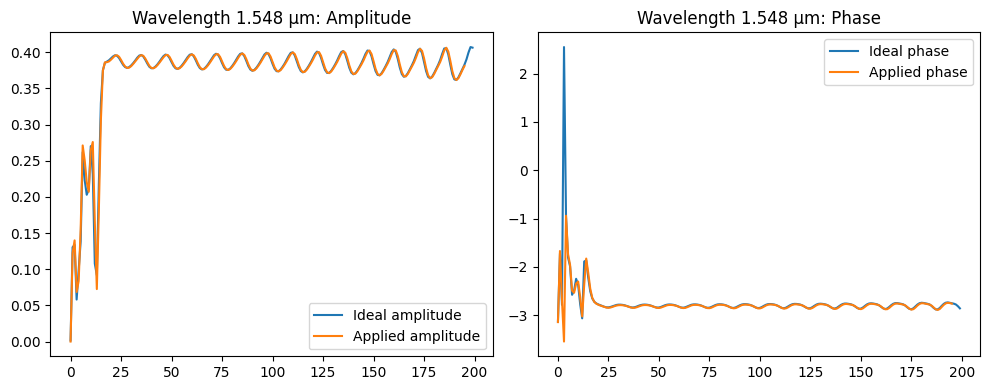

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 8.768929719924927
Simulation time: 8.772 s
Found better alignment at index: 50 with error: 0.06467702332399929
Found better alignment at index: 51 with error: 0.05627476204314242
Found better alignment at index: 70 with error: 0.05583892556735634
Best alignment at index: 70
amplitude: 0.20831107513278915
phase: -3.791384455100377


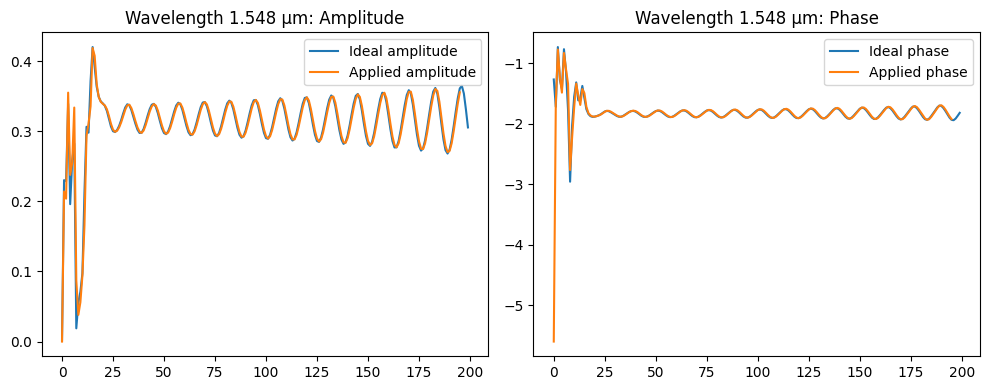

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 9.249875783920288
Simulation time: 9.252 s
Found better alignment at index: 50 with error: 0.004970177146121852
Found better alignment at index: 54 with error: 0.004592833933538545
Found better alignment at index: 61 with error: 0.004589778620051524
Found better alignment at index: 73 with error: 0.004587851641913405
Found better alignment at index: 79 with error: 0.004584905793915328
Best alignment at index: 79
amplitude: 0.2063954993672773
phase: 2.5013603535448214


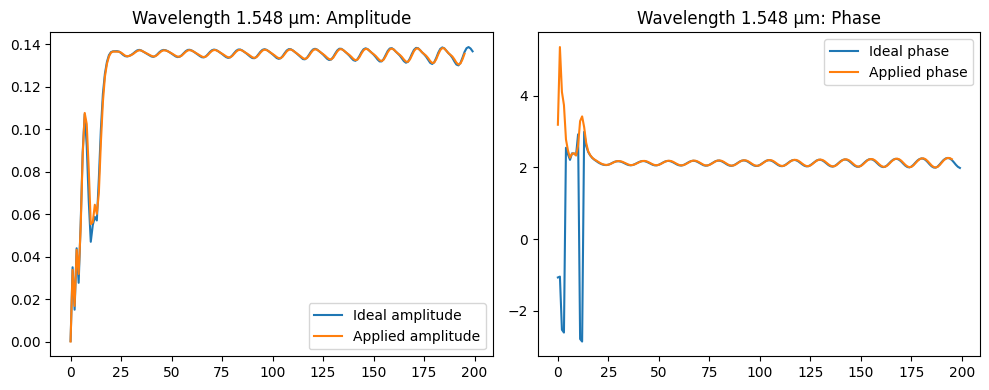



neg_bias:

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 8.286880731582642
Simulation time: 8.295 s
Found better alignment at index: 50 with error: 0.003067410133652654
Found better alignment at index: 51 with error: 0.002615164525488473
Found better alignment at index: 52 with error: 0.0023076444733495446
Found better alignment at index: 53 with error: 0.0022463201438272596
Found better alignment at index: 60 with error: 0.002216959505113311
Found better alignment at index: 78 with error: 0.002213090310255977
Best alignment at index: 78
amplitude: 0.2007171852492325
phase: 2.5219919609140393


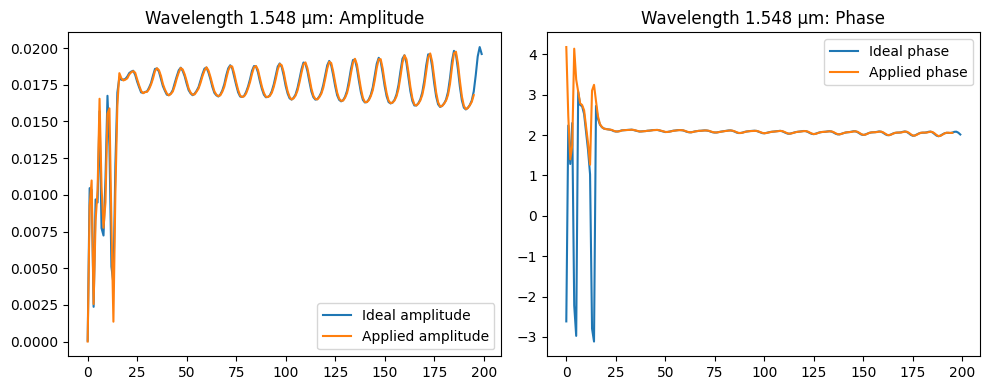

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 8.41813588142395
Simulation time: 8.418 s
Found better alignment at index: 50 with error: 0.05066760306919022
Found better alignment at index: 55 with error: 0.05026974699645548
Found better alignment at index: 56 with error: 0.04753690521154696
Found better alignment at index: 74 with error: 0.04749560835544264
Best alignment at index: 74
amplitude: 0.2080967059939223
phase: 2.4843192374803436


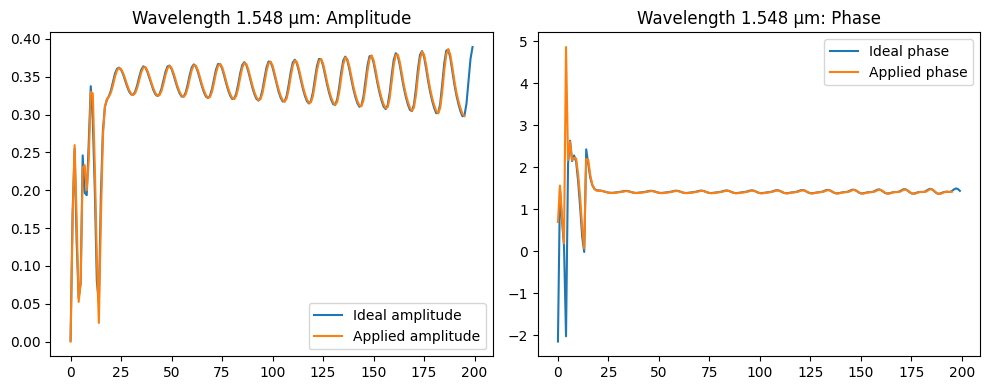

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 7.384280443191528
Simulation time: 7.387 s
Found better alignment at index: 50 with error: 0.01865971679130274
Found better alignment at index: 51 with error: 0.017768128371704075
Found better alignment at index: 52 with error: 0.014604805202353275
Found better alignment at index: 53 with error: 0.013079565278067641
Best alignment at index: 53
amplitude: 0.20712572234169532
phase: 2.4760281986984185


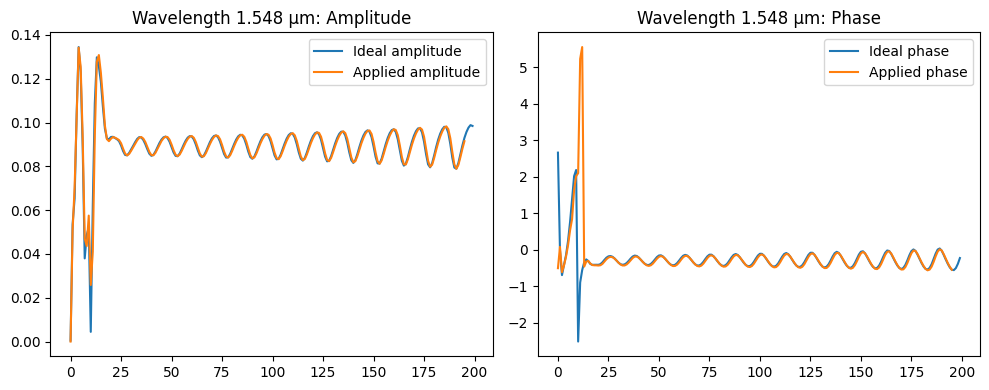

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 7.380707263946533
Simulation time: 7.384 s
Found better alignment at index: 50 with error: 0.0036847716005684325
Found better alignment at index: 51 with error: 0.003625041585836612
Found better alignment at index: 52 with error: 0.003568973964586969
Found better alignment at index: 53 with error: 0.003559604489835183
Found better alignment at index: 54 with error: 0.003209285115244679
Found better alignment at index: 55 with error: 0.0031743049025154736
Found better alignment at index: 60 with error: 0.0031522669114287826
Found better alignment at index: 67 with error: 0.003128093304189651
Found bett

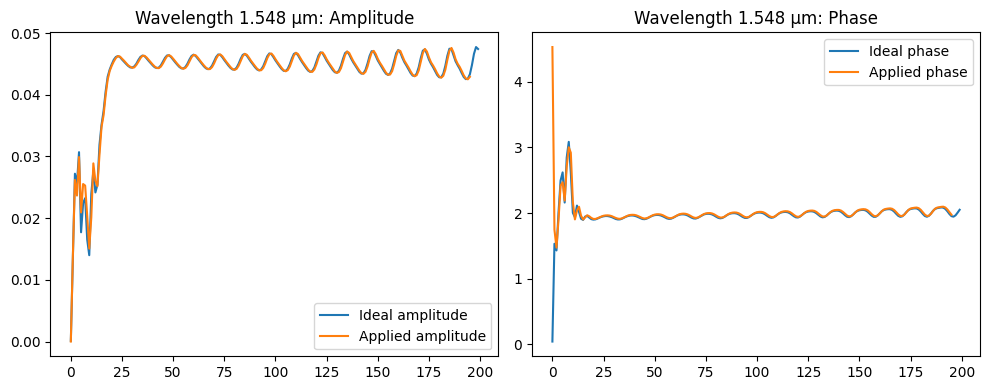



pos_bias:

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 7.285914659500122
Simulation time: 7.293 s
Found better alignment at index: 50 with error: 0.0269331880142757
Found better alignment at index: 57 with error: 0.025626973178854394
Found better alignment at index: 107 with error: 0.02562341020104199
Found better alignment at index: 149 with error: 0.02562327654890665
Best alignment at index: 149
amplitude: 0.20843190067483636
phase: -3.807627094194665


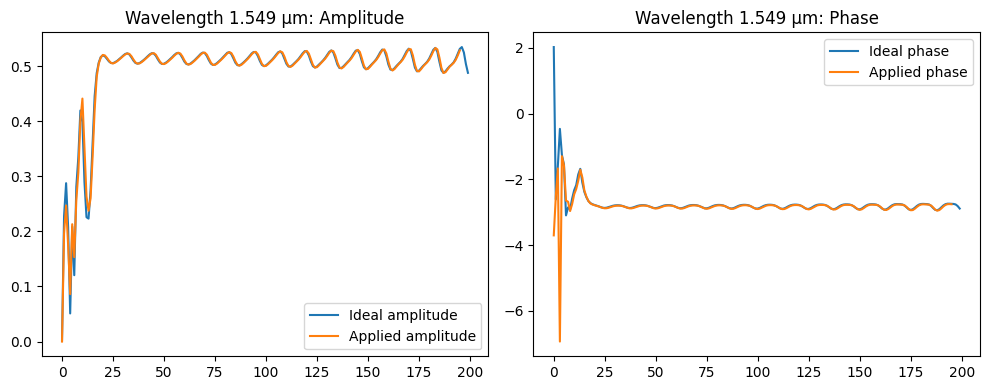

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 7.2387847900390625
Simulation time: 7.251 s
Found better alignment at index: 50 with error: 0.019285890284152736
Found better alignment at index: 51 with error: 0.01777095129672728
Best alignment at index: 51
amplitude: 0.2077725758290893
phase: 2.4917764303195327


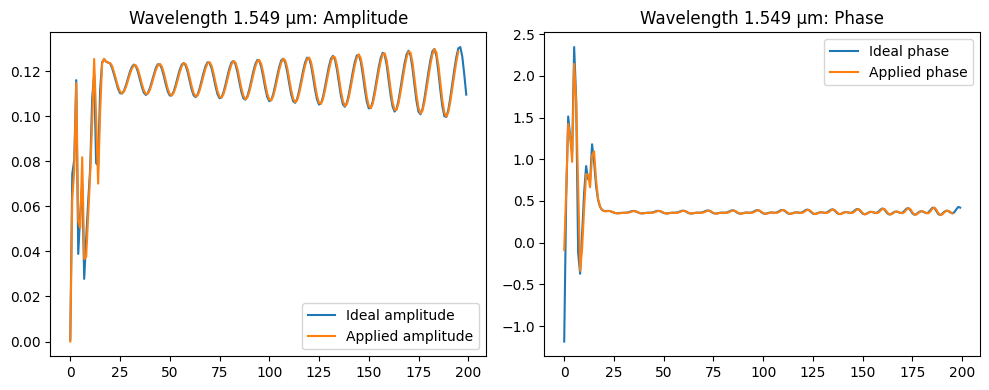

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 7.296127557754517
Simulation time: 7.310 s
Found better alignment at index: 50 with error: 0.009263782061865181
Found better alignment at index: 51 with error: 0.008985745537741554
Found better alignment at index: 52 with error: 0.007724156253818139
Found better alignment at index: 53 with error: 0.00743755431040346
Found better alignment at index: 59 with error: 0.007341533199768873
Found better alignment at index: 71 with error: 0.007337742138809695
Found better alignment at index: 96 with error: 0.007317708333198618
Best alignment at index: 96
amplitude: 0.20722924815846872
phase: -3.78765447965800

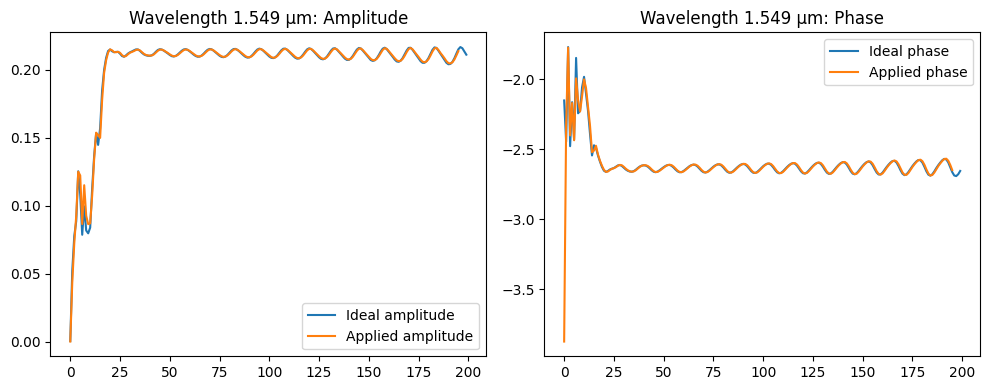

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 9.299952745437622
Simulation time: 9.302 s
Found better alignment at index: 50 with error: 0.008721561759419702
Found better alignment at index: 51 with error: 0.007566541101512526
Found better alignment at index: 52 with error: 0.006758256671269609
Found better alignment at index: 59 with error: 0.006675826926024908
Found better alignment at index: 77 with error: 0.006663191370053759
Found better alignment at index: 102 with error: 0.006642890805590959
Best alignment at index: 102
amplitude: 0.2046084789331223
phase: -3.7718683545345373


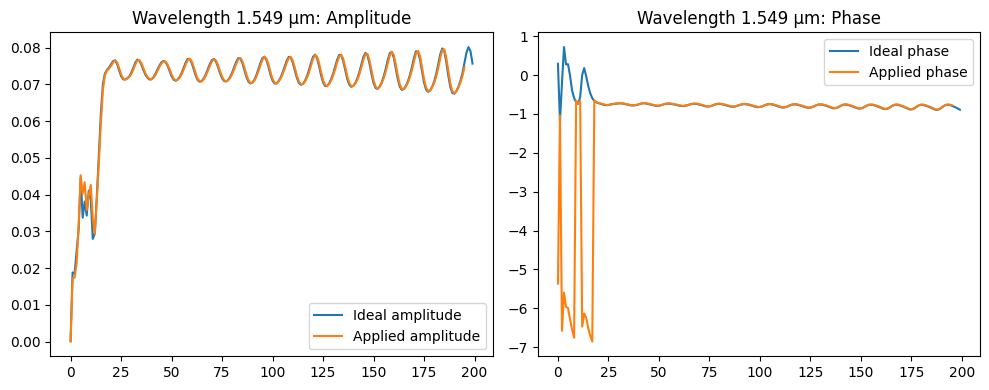



neg_bias:

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 9.228217124938965
Simulation time: 9.233 s
Found better alignment at index: 50 with error: 0.0025046833976264545
Found better alignment at index: 53 with error: 0.00249216988993815
Found better alignment at index: 54 with error: 0.002148292889023708
Found better alignment at index: 55 with error: 0.002046728214891293
Found better alignment at index: 74 with error: 0.0020449656174440323
Best alignment at index: 74
amplitude: 0.1992796966459724
phase: 2.5263678443843265


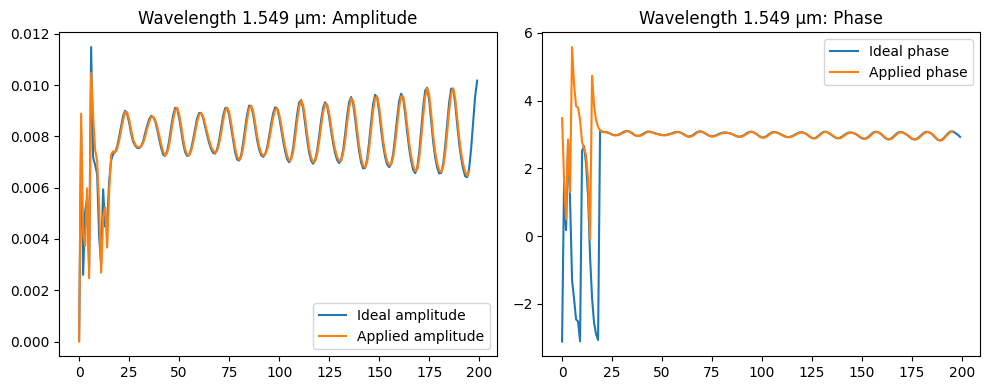

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 9.426035404205322
Simulation time: 9.426 s
Found better alignment at index: 50 with error: 0.02289109439907338
Found better alignment at index: 52 with error: 0.021548051088881498
Found better alignment at index: 53 with error: 0.019078095213849282
Found better alignment at index: 59 with error: 0.018910700056368333
Found better alignment at index: 60 with error: 0.01868781861912303
Found better alignment at index: 66 with error: 0.0186844255925445
Found better alignment at index: 72 with error: 0.018642745714788782
Found better alignment at index: 134 with error: 0.018641159537092132
Best alignment a

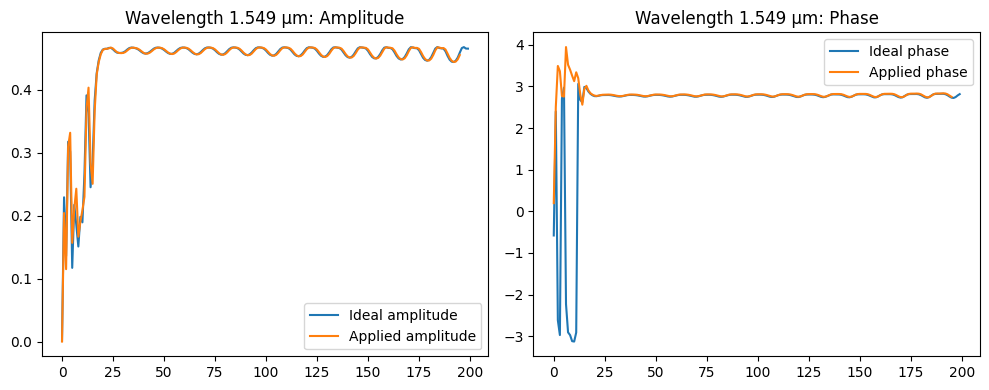

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 9.424691915512085
Simulation time: 9.443 s
Found better alignment at index: 50 with error: 0.04303761137204628
Found better alignment at index: 51 with error: 0.037679223814081106
Found better alignment at index: 57 with error: 0.03759880614966897
Found better alignment at index: 70 with error: 0.03743304654456655
Best alignment at index: 70
amplitude: 0.20830108302262906
phase: 2.4813880288212644


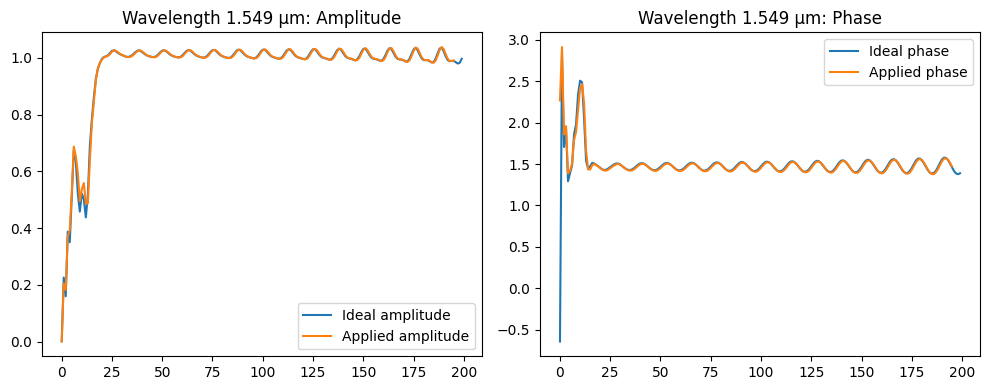

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 9.389974117279053
Simulation time: 9.393 s
Found better alignment at index: 50 with error: 0.008411114933008485
Found better alignment at index: 68 with error: 0.008395416232052038
Best alignment at index: 68
amplitude: 0.20554486276213182
phase: -3.7913129184358665


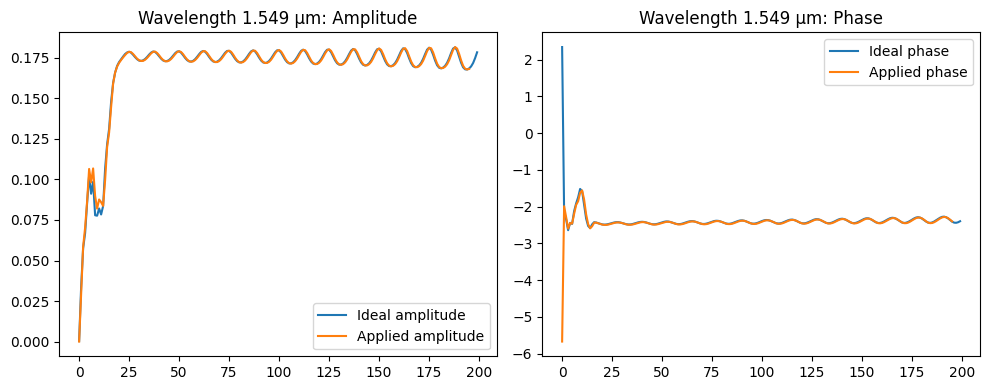



pos_bias:

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 9.21568250656128
Simulation time: 9.219 s
Found better alignment at index: 50 with error: 0.006285767395546856
Found better alignment at index: 51 with error: 0.005608285676042593
Found better alignment at index: 52 with error: 0.005420753054018316
Found better alignment at index: 53 with error: 0.005350102002384287
Best alignment at index: 53
amplitude: 0.2065496951025891
phase: 2.494685085341842


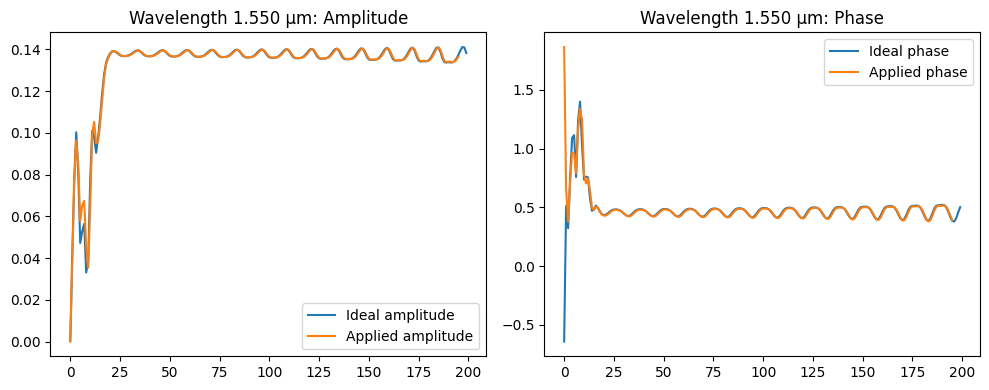

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.975535869598389
Simulation time: 14.980 s
Found better alignment at index: 50 with error: 0.02840211908782979
Found better alignment at index: 53 with error: 0.027900703026293168
Found better alignment at index: 54 with error: 0.024639944376719836
Found better alignment at index: 61 with error: 0.024592650115701283
Found better alignment at index: 136 with error: 0.024591169389482796
Best alignment at index: 136
amplitude: 0.2083605583549831
phase: -3.778111837506712


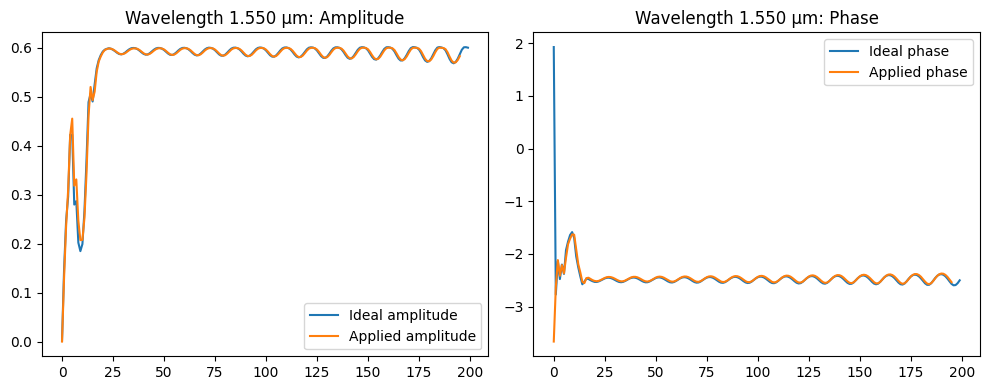

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 15.445559024810791
Simulation time: 15.449 s
Found better alignment at index: 50 with error: 0.06648172296783583
Found better alignment at index: 51 with error: 0.06209056570159705
Found better alignment at index: 88 with error: 0.06200426784356669
Found better alignment at index: 113 with error: 0.06193201337224403
Found better alignment at index: 145 with error: 0.061757168377119497
Best alignment at index: 145
amplitude: 0.2078968175435511
phase: 2.4880682199356103


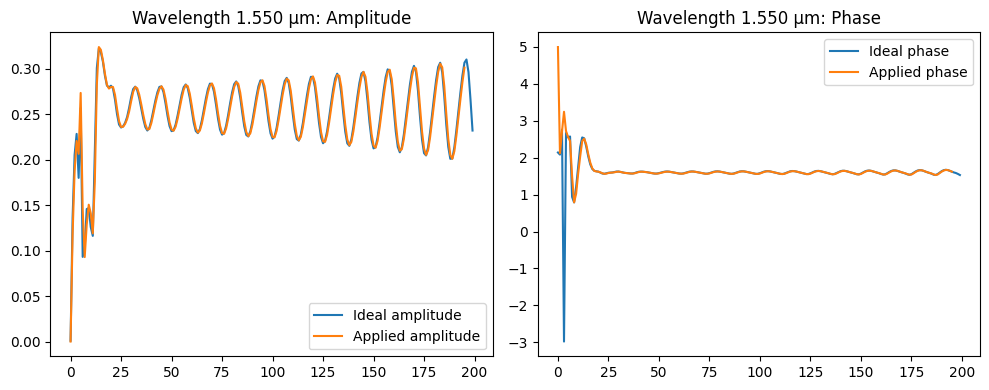

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.80057144165039
Simulation time: 14.809 s
Found better alignment at index: 50 with error: 0.006863996292107214
Found better alignment at index: 56 with error: 0.006704724168267622
Found better alignment at index: 131 with error: 0.006697505587750098
Best alignment at index: 131
amplitude: 0.20294762348558046
phase: -3.7819497456836713


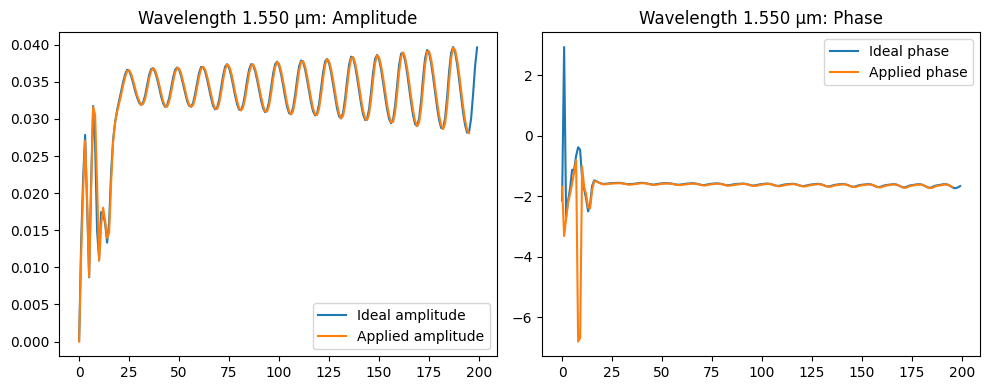



neg_bias:

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 15.012059926986694
Simulation time: 15.015 s
Found better alignment at index: 50 with error: 0.0014943448037997137
Found better alignment at index: 55 with error: 0.0014920955305473813
Found better alignment at index: 61 with error: 0.0014885749095837977
Found better alignment at index: 74 with error: 0.0014881750670816074
Best alignment at index: 74
amplitude: 0.2001983051157293
phase: 2.531527002401849


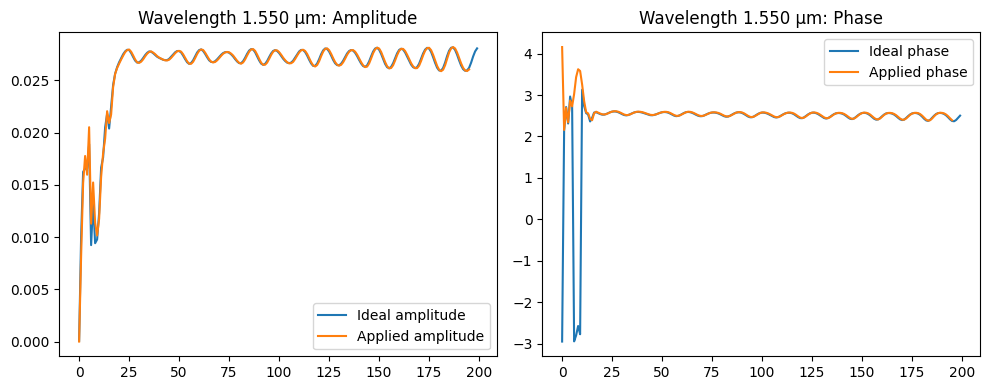

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.860578536987305
Simulation time: 14.861 s
Found better alignment at index: 50 with error: 0.004363458114640841
Found better alignment at index: 53 with error: 0.004208097719506483
Found better alignment at index: 54 with error: 0.0038414609415848276
Found better alignment at index: 72 with error: 0.003841372910837647
Best alignment at index: 72
amplitude: 0.20543122251332904
phase: 2.5142729617179387


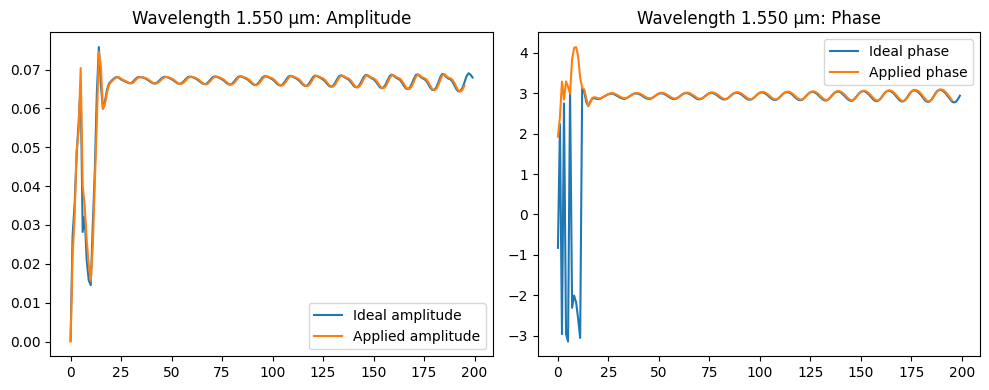

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.850339412689209
Simulation time: 14.861 s
Found better alignment at index: 50 with error: 0.0018233111394867635
Found better alignment at index: 55 with error: 0.0018092612165949529
Found better alignment at index: 62 with error: 0.0017992830012073878
Found better alignment at index: 68 with error: 0.001792564084629528
Found better alignment at index: 87 with error: 0.0017924468212532636
Best alignment at index: 87
amplitude: 0.20114544603766502
phase: 2.535106970923025


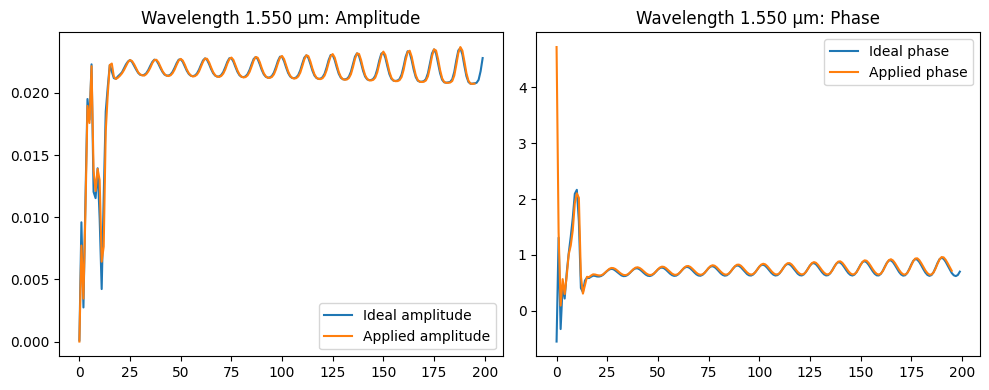

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.940459251403809
Simulation time: 14.946 s
Found better alignment at index: 50 with error: 0.00543932028170632
Found better alignment at index: 51 with error: 0.004787123858330789
Found better alignment at index: 52 with error: 0.004769557104462039
Found better alignment at index: 64 with error: 0.0046904858318815735
Best alignment at index: 64
amplitude: 0.20277117342706685
phase: 2.5221676060817355


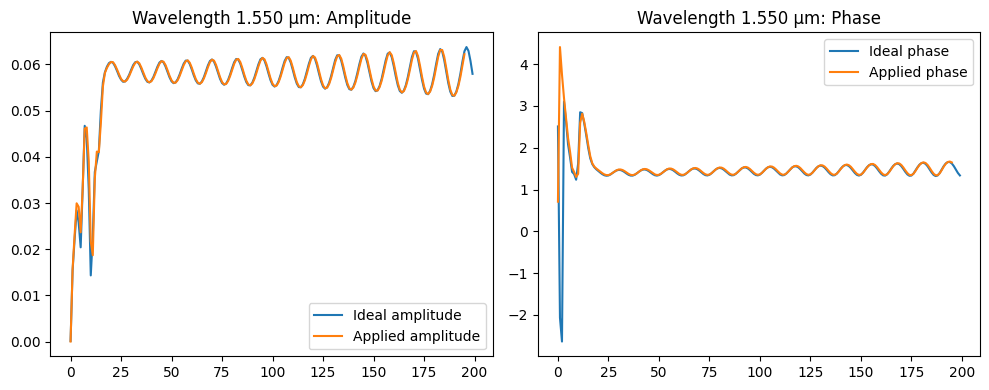



pos_bias:

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.816196918487549
Simulation time: 14.824 s
Found better alignment at index: 50 with error: 0.02859018401873326
Found better alignment at index: 52 with error: 0.0263155767735218
Found better alignment at index: 53 with error: 0.021801821488098932
Found better alignment at index: 60 with error: 0.02132346586354172
Found better alignment at index: 85 with error: 0.02131483217483301
Best alignment at index: 85
amplitude: 0.20810753975234159
phase: 2.5170143413787622


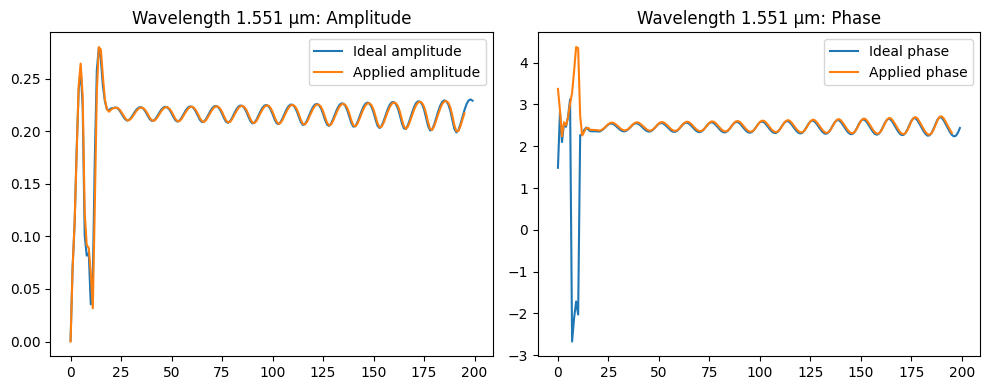

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 15.023417472839355
Simulation time: 15.031 s
Found better alignment at index: 50 with error: 0.0424192578601149
Found better alignment at index: 54 with error: 0.04181733912185967
Found better alignment at index: 55 with error: 0.0372579596457868
Found better alignment at index: 61 with error: 0.03718917888222039
Best alignment at index: 61
amplitude: 0.2077999762009449
phase: -3.809428427463099


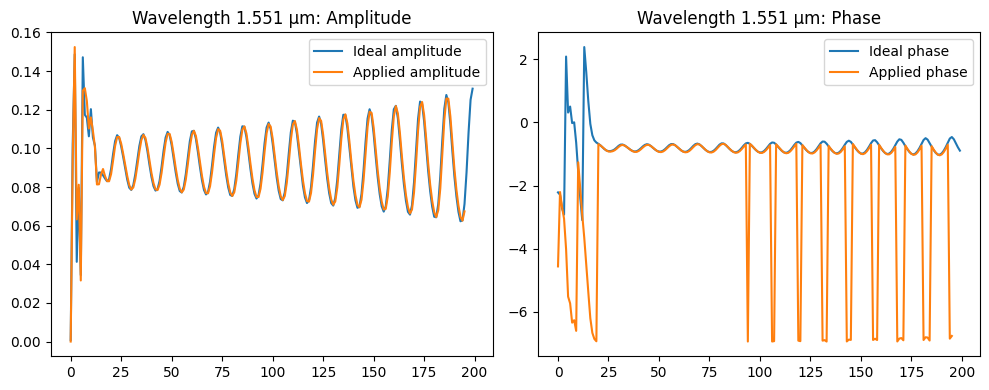

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.861364126205444
Simulation time: 14.861 s
Found better alignment at index: 50 with error: 0.01759974722904784
Found better alignment at index: 51 with error: 0.015577759874919155
Found better alignment at index: 52 with error: 0.0138543616638768
Found better alignment at index: 53 with error: 0.013217245024504935
Found better alignment at index: 66 with error: 0.013111797277837112
Best alignment at index: 66
amplitude: 0.20657122811145393
phase: -3.787066917589197


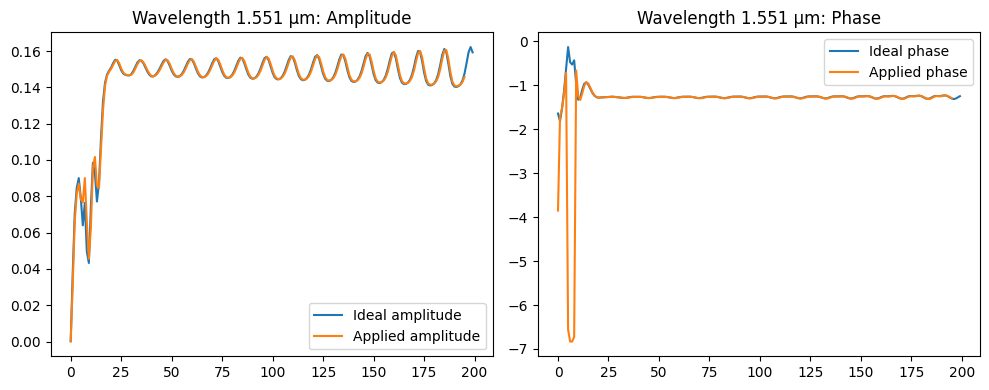

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.91043496131897
Simulation time: 14.918 s
Found better alignment at index: 50 with error: 0.0025571982183797545
Found better alignment at index: 51 with error: 0.00252388873009947
Found better alignment at index: 52 with error: 0.0020352413662262114
Found better alignment at index: 53 with error: 0.0018578881042667088
Found better alignment at index: 59 with error: 0.0018405160164279076
Found better alignment at index: 65 with error: 0.001836813024755802
Found better alignment at index: 90 with error: 0.0018368098236965812
Best alignment at index: 90
amplitude: 0.19637792233171064
phase: -3.76464574

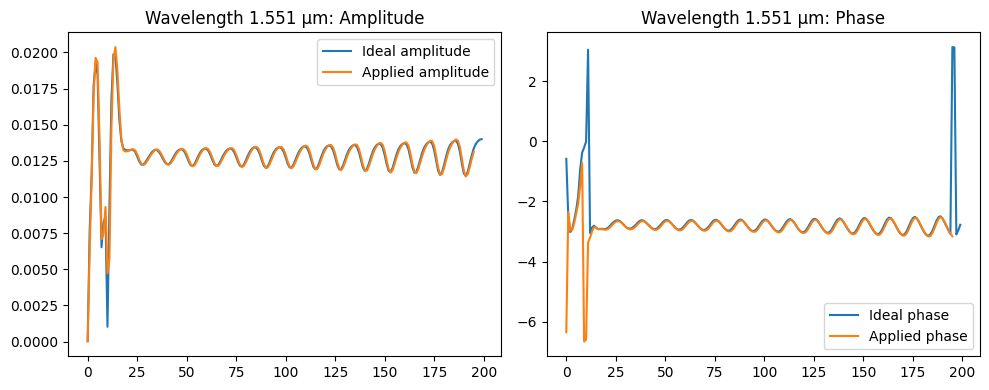



neg_bias:

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 17.050363302230835
Simulation time: 17.073 s
Found better alignment at index: 50 with error: 0.007618188710492541
Found better alignment at index: 51 with error: 0.006891212072950348
Found better alignment at index: 76 with error: 0.00689082532545787
Best alignment at index: 76
amplitude: 0.20394334016707077
phase: -3.76871776098144


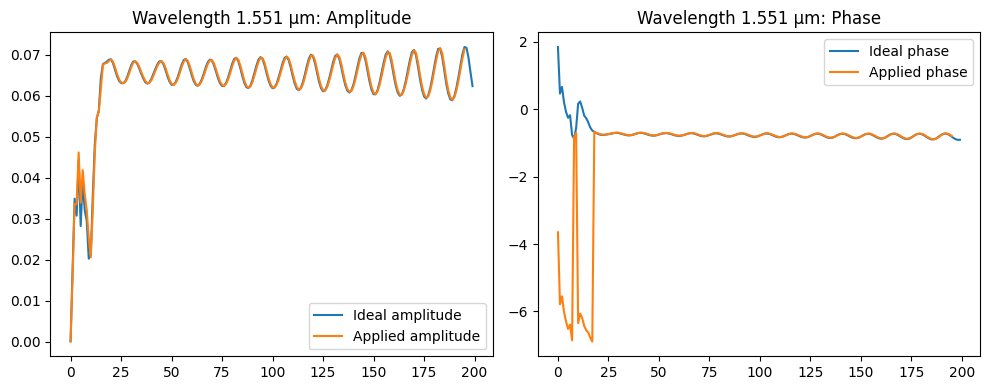

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.992540121078491
Simulation time: 14.995 s
Found better alignment at index: 50 with error: 0.061313769928559116
Found better alignment at index: 51 with error: 0.05739035400202803
Found better alignment at index: 52 with error: 0.05339918764947134
Found better alignment at index: 53 with error: 0.05016980117662425
Found better alignment at index: 54 with error: 0.0501358225859548
Found better alignment at index: 66 with error: 0.04952275153587765
Best alignment at index: 66
amplitude: 0.20826195962264188
phase: 2.48889474824556


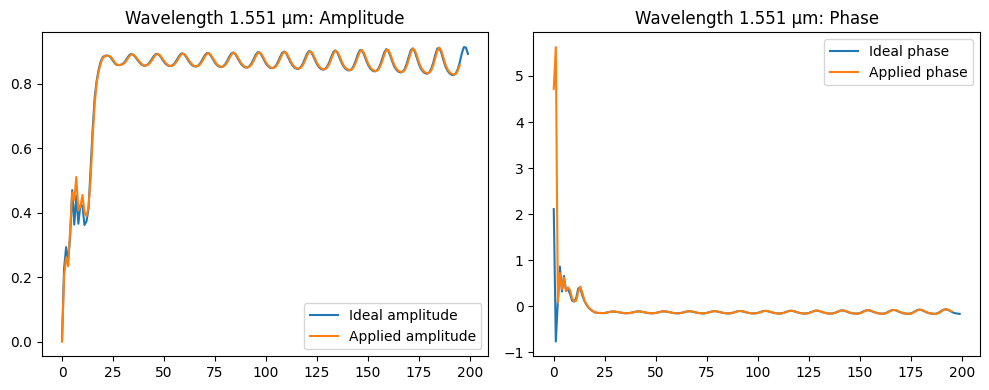

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.710569858551025
Simulation time: 14.714 s
Found better alignment at index: 50 with error: 0.0017492911209252581
Found better alignment at index: 51 with error: 0.0016442885694120141
Found better alignment at index: 57 with error: 0.0016330035249763673
Found better alignment at index: 82 with error: 0.0016312055663538678
Found better alignment at index: 113 with error: 0.0016307382381789918
Found better alignment at index: 145 with error: 0.0016306689325341394
Best alignment at index: 145
amplitude: 0.20016121380927873
phase: -3.7858758000712864


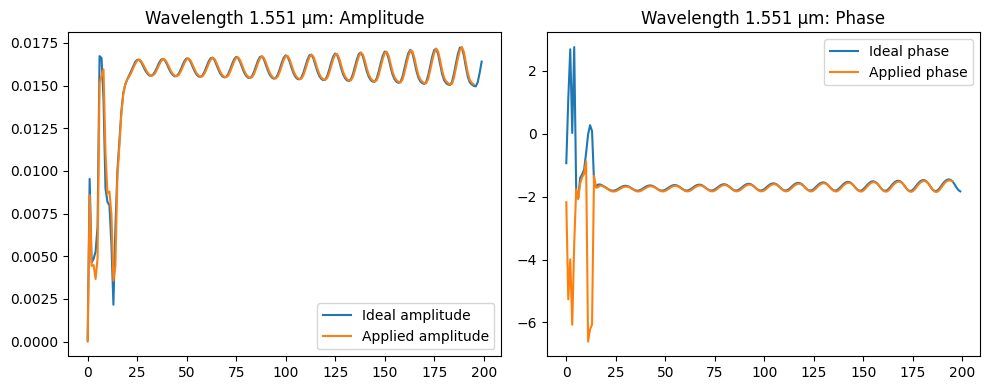

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.932912349700928
Simulation time: 14.939 s
Found better alignment at index: 50 with error: 0.002757781560025488
Found better alignment at index: 51 with error: 0.002355165175503033
Found better alignment at index: 70 with error: 0.0023511368102040486
Found better alignment at index: 120 with error: 0.002349694019564567
Best alignment at index: 120
amplitude: 0.19310481988781011
phase: -3.730774738527135


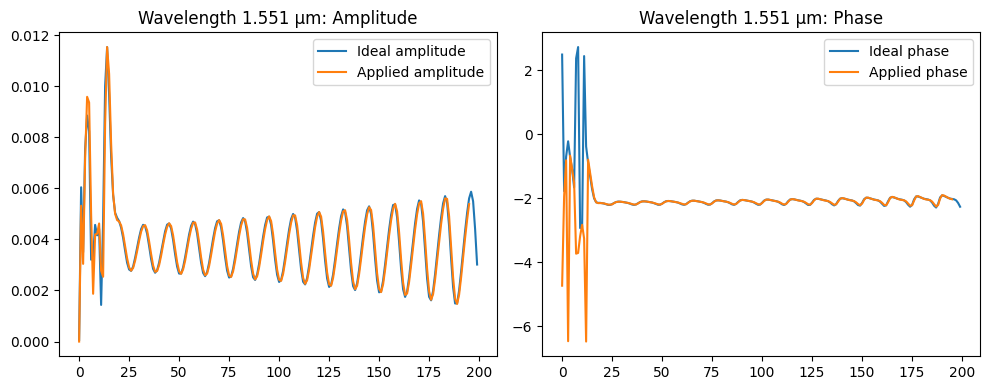



pos_bias:

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 13.111863613128662
Simulation time: 13.120 s
Found better alignment at index: 50 with error: 0.049132585580506385
Found better alignment at index: 51 with error: 0.04296201612469092
Found better alignment at index: 70 with error: 0.04257126300180715
Found better alignment at index: 101 with error: 0.042562434325896445
Found better alignment at index: 145 with error: 0.042560907856309164
Best alignment at index: 145
amplitude: 0.2082402204112029
phase: -3.81581217830029


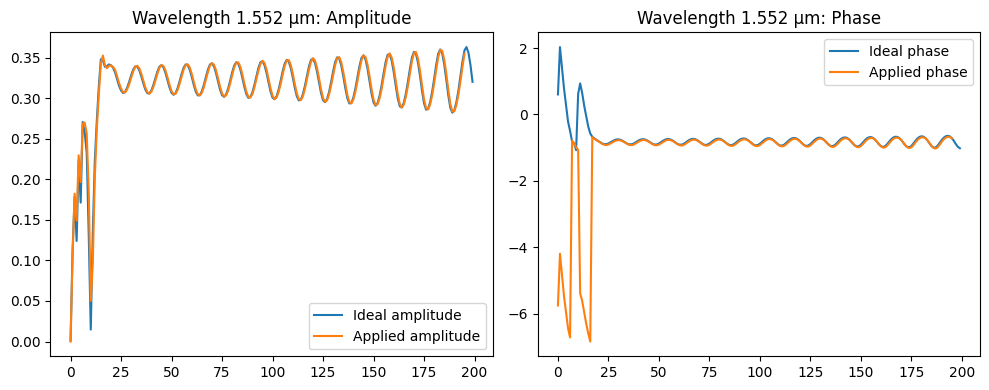

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 12.960415124893188
Simulation time: 12.971 s
Found better alignment at index: 50 with error: 0.020449752525872965
Found better alignment at index: 51 with error: 0.017271293882620765
Found better alignment at index: 57 with error: 0.017138274358741008
Best alignment at index: 57
amplitude: 0.2078980651708671
phase: 2.4896984881847772


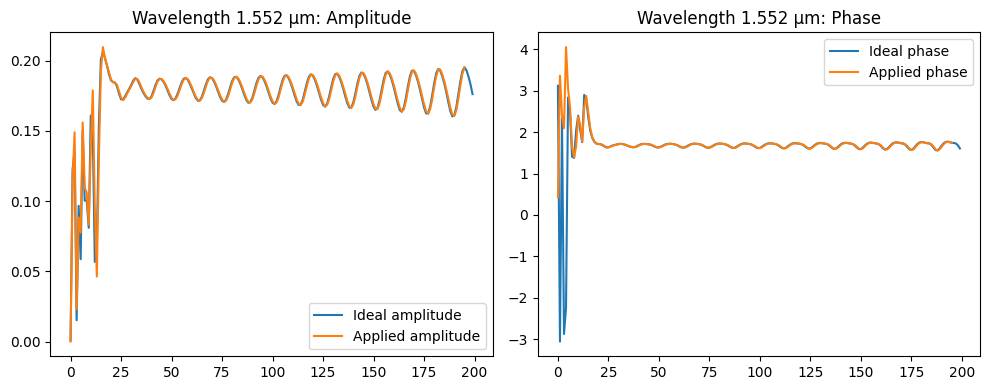

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 13.231586217880249
Simulation time: 13.239 s
Found better alignment at index: 50 with error: 0.05328691871153368
Found better alignment at index: 75 with error: 0.05320571405485298
Found better alignment at index: 144 with error: 0.05319561968915375
Best alignment at index: 144
amplitude: 0.20833078562127333
phase: -3.8062550907823054


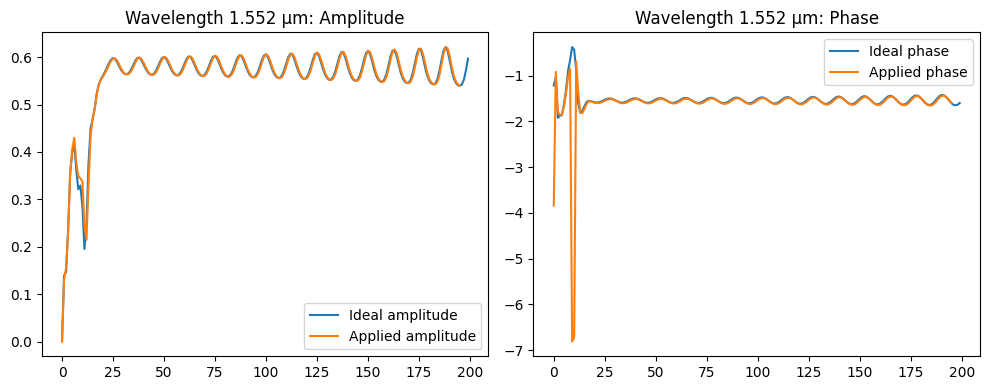

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 13.05138087272644
Simulation time: 13.054 s
Found better alignment at index: 50 with error: 0.0038039370342697466
Found better alignment at index: 58 with error: 0.003800943873596679
Found better alignment at index: 67 with error: 0.0037974415613574674
Best alignment at index: 67
amplitude: 0.20566886835830356
phase: 2.496875891618675


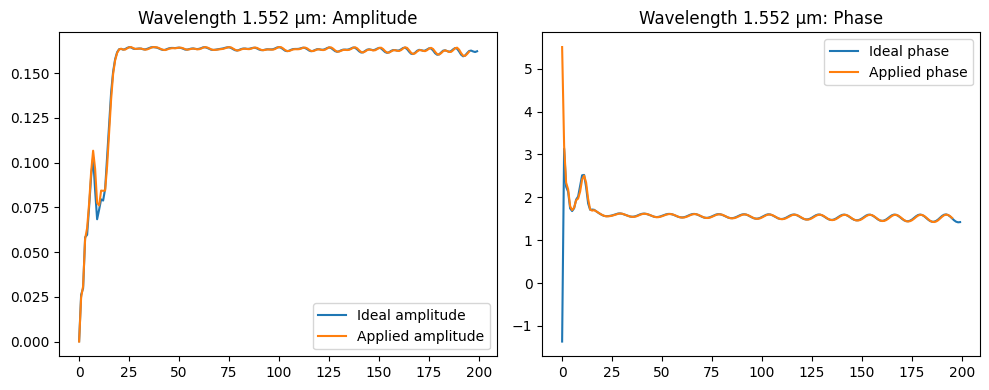



neg_bias:

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 13.224616050720215
Simulation time: 13.227 s
Found better alignment at index: 50 with error: 0.06372166871089645
Found better alignment at index: 51 with error: 0.057973973381202484
Best alignment at index: 51
amplitude: 0.20793191433787855
phase: 2.4992445196865045


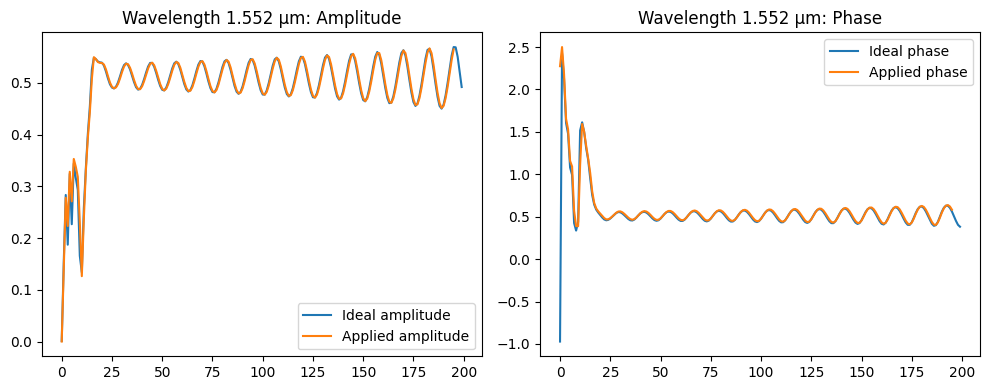

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 13.325882911682129
Simulation time: 13.331 s
Found better alignment at index: 50 with error: 0.08344118597137583
Found better alignment at index: 56 with error: 0.0825386389962196
Found better alignment at index: 62 with error: 0.08246819665051915
Best alignment at index: 62
amplitude: 0.20846308790526102
phase: -3.7871872431931894


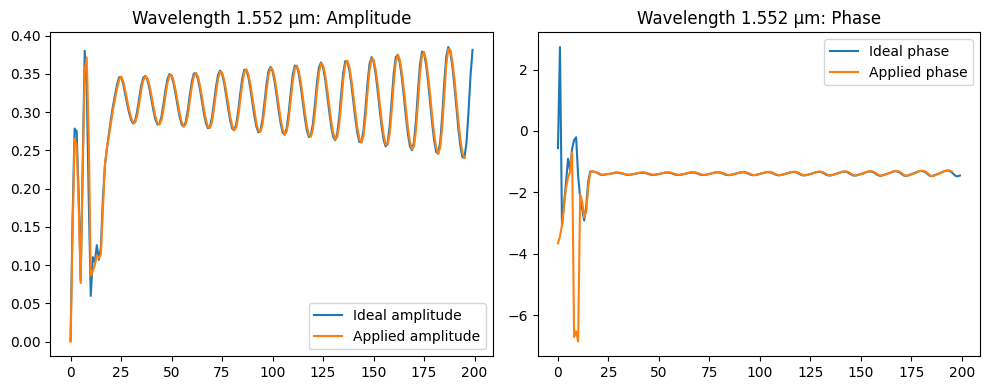

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.009071588516235
Simulation time: 14.009 s
Found better alignment at index: 50 with error: 0.0023281364921685452
Found better alignment at index: 51 with error: 0.002274990308140524
Found better alignment at index: 57 with error: 0.0022507315769838433
Best alignment at index: 57
amplitude: 0.19881208261810368
phase: 2.528722519221307


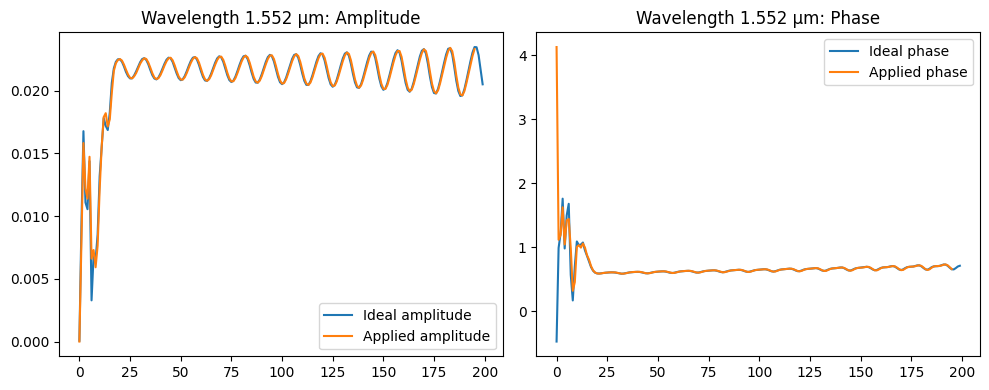

(5120000, 40)
Initial state for laser1 computed
Initial state for data_source computed
Initial state for pm1 computed
Initial state for pm2 computed
Initial state for wg1 computed
Initial state for wg2 computed
Initial state for y1 computed
Initial state for y2 computed
Initial state for _optical_termination0 computed
Starting simulation...
Completed 1 / 1 chunks Estimated time remaining: 14.946694135665894
Simulation time: 14.951 s
Found better alignment at index: 50 with error: 0.007502314993344119
Found better alignment at index: 51 with error: 0.006449190640559351
Found better alignment at index: 52 with error: 0.005584092383438992
Found better alignment at index: 53 with error: 0.005516335650504704
Found better alignment at index: 65 with error: 0.005468431354260064
Best alignment at index: 65
amplitude: 0.20266921282855868
phase: 2.5116580627071112


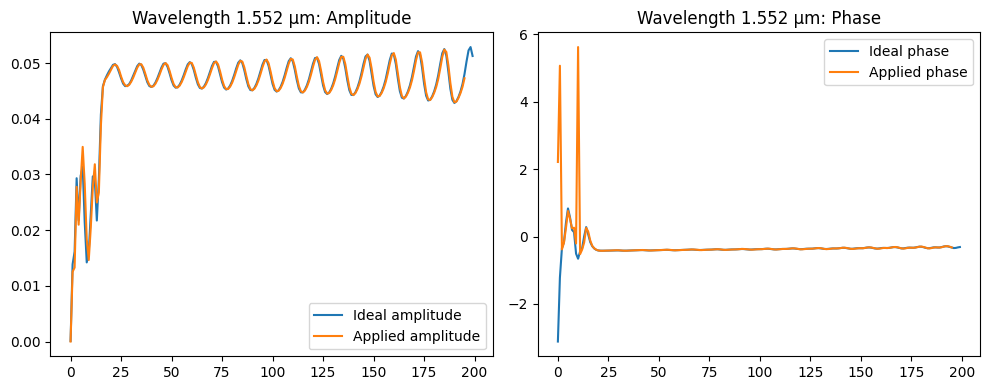

In [82]:
wavelengths = [1.548,1.549,1.55,1.551,1.552]

pos_amp_bias = []
pos_phase_bias = []
neg_amp_bias = []
neg_phase_bias = []
best_alignment_negative = []
best_alignment_positive = []
for i, w in enumerate(wavelengths):
    print("\n\npos_bias:\n")
    x_pos_current = xpos[:, i::5]
    x_neg_current = xneg[:, i::5]

    simulation_parameters = SampleModeSimulationParameters(
        optical_baseband_wavelengths=jnp.array([w], jnp.float32),
        num_time_steps=int(len(t)),
        sampling_period=dt,
    )

    max_amp_pos = np.max(np.abs(weights_pos))

    for j, weight in enumerate(weights_pos[i::5]):
        def phase_mod(amp):
            return 2 * np.arccos(amp)
        
        x_pos_value = x_pos_current[:,j]
        input_data = np.stack(
            [v["output"].amplitude[:, :, 0] for v in l.values()],
            axis=0
        )
        input_data = input_data.transpose(1, 2, 0)
        input_data = input_data.reshape(input_data.shape[0], int(input_data.shape[1]*input_data.shape[2]))
        print(input_data.shape)

        input_array = input_data[:len(t), i + j*5]
        settings["data_source"] = {
            "data_array": jnp.array(input_array[:,None]),
            "wavelengths": wavelengths,
        }

        phase_1 = phase_mod(np.abs(weight / (max_amp_pos + 1.0)))
        phase_2 = -0.5 * phase_1 + np.angle(weight)

        settings["pm1"] = {"mod_signal": phase_1 * jnp.ones_like(t)}
        settings["pm2"] = {"mod_signal": phase_2 * jnp.ones_like(t)}
        ideal_aligned = x_pos_value[:200] * weight
        results = sim.run(simulation_parameters=simulation_parameters, settings=settings)

        output = results["out"]["output"].amplitude[42::512, 0, 0]
        out_np = np.asarray(output)
        error = 1000
        error_check = 1000
        best_alignment = 49
        while best_alignment < 150:
            best_alignment += 1
            ref = x_pos_value[best_alignment]
            desired_pos_amp = np.abs(ref * weight)
            desired_pos_phase = np.angle(ref * weight)

            amp_bias = float(desired_pos_amp / (np.abs(out_np[best_alignment] * (max_amp_pos+1.0))))
            phase_bias = float(desired_pos_phase - np.angle(out_np[best_alignment]))
            error = np.linalg.norm(
                (np.abs((out_np[50:] * (max_amp_pos+1.0)) * amp_bias) - np.abs(ideal_aligned)[50:len(out_np)])
            )
            if error < error_check:
                print("Found better alignment at index:", best_alignment, "with error:", error)
                error_check = error
                final_amp_bias = amp_bias
                final_phase_bias = phase_bias
                final_alignment = best_alignment


        print("Best alignment at index:", final_alignment)
        print("amplitude:", final_amp_bias)
        print("phase:", final_phase_bias)
        pos_amp_bias.append(final_amp_bias)
        pos_phase_bias.append(final_phase_bias)
        best_alignment_positive.append(final_alignment)

        

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.title(f"Wavelength {w:.3f} μm: Amplitude")
        plt.plot(np.abs(ideal_aligned), label='Ideal amplitude')
        plt.plot(np.abs((out_np * (max_amp_pos+1.0)) * final_amp_bias), label='Applied amplitude')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.title(f"Wavelength {w:.3f} μm: Phase")
        plt.plot(np.angle(ideal_aligned), label='Ideal phase')
        plt.plot(np.angle(out_np) + final_phase_bias, label='Applied phase')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
    max_amp_neg = np.max(np.abs(weights_neg))
    print("\n\nneg_bias:\n")
    for j, weight in enumerate(weights_neg[i::5]):
        def phase_mod(amp):
            return 2 * np.arccos(amp)
        
        x_neg_value = x_neg_current[:,j]
        input_data = np.stack(
            [v["output"].amplitude[:, :, 0] for v in l.values()],
            axis=0
        )
        input_data = input_data.transpose(1, 2, 0)
        input_data = input_data.reshape(input_data.shape[0], int(input_data.shape[1]*input_data.shape[2]))
        print(input_data.shape)

        input_array = input_data[:len(t), i + j*5 + 20]
        settings["data_source"] = {
            "data_array": jnp.array(input_array[:,None]),
            "wavelengths": wavelengths,
        }

        phase_1 = phase_mod(np.abs(weight / (max_amp_neg + 1.0)))
        phase_2 = -0.5 * phase_1 + np.angle(weight)

        settings["pm1"] = {"mod_signal": phase_1 * jnp.ones_like(t)}
        settings["pm2"] = {"mod_signal": phase_2 * jnp.ones_like(t)}
        ideal_aligned = x_neg_value[:200] * weight
        results = sim.run(simulation_parameters=simulation_parameters, settings=settings)

        output = results["out"]["output"].amplitude[42::512, 0, 0]
        out_np = np.asarray(output)
        error = 1000
        error_check = 1000
        best_alignment = 49
        while best_alignment < 150:
            best_alignment += 1
            ref = x_neg_value[best_alignment]
            desired_neg_amp = np.abs(ref * weight)
            desired_neg_phase = np.angle(ref * weight)

            amp_bias = float(desired_neg_amp / (np.abs(out_np[best_alignment] * (max_amp_neg+1.0))))
            phase_bias = float(desired_neg_phase - np.angle(out_np[best_alignment]))
            error = np.linalg.norm(
                (np.abs((out_np[50:] * (max_amp_neg+1.0)) * amp_bias) - np.abs(ideal_aligned)[50:len(out_np)])
            )
            if error < error_check:
                print("Found better alignment at index:", best_alignment, "with error:", error)
                error_check = error
                final_amp_bias = amp_bias
                final_phase_bias = phase_bias
                final_alignment = best_alignment


        print("Best alignment at index:", final_alignment)
        print("amplitude:", final_amp_bias)
        print("phase:", final_phase_bias)
        neg_amp_bias.append(final_amp_bias)
        neg_phase_bias.append(final_phase_bias)
        best_alignment_negative.append(final_alignment)

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.title(f"Wavelength {w:.3f} μm: Amplitude")
        plt.plot(np.abs(ideal_aligned), label='Ideal amplitude')
        plt.plot(np.abs((out_np * (max_amp_neg+1.0)) * final_amp_bias), label='Applied amplitude')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.title(f"Wavelength {w:.3f} μm: Phase")
        plt.plot(np.angle(ideal_aligned), label='Ideal phase')
        plt.plot(np.angle(out_np) + final_phase_bias, label='Applied phase')
        plt.legend()
        plt.tight_layout()
        plt.show()

np.savez_compressed(
    "bias_values_3.0_bias.npz",
    pos_amp   = np.array(pos_amp_bias,   dtype=np.float32),
    pos_phase = np.array(pos_phase_bias, dtype=np.float32),
    neg_amp   = np.array(neg_amp_bias,   dtype=np.float32),
    neg_phase = np.array(neg_phase_bias, dtype=np.float32),
)

Best sampling phase = 40 samples  (~0.40 ps) from your trace start


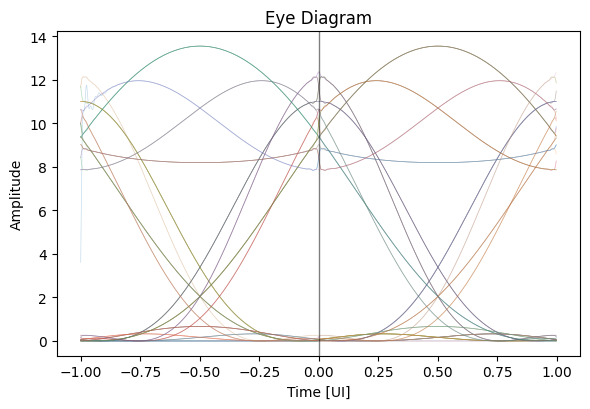

Collected 97 decision samples.


In [73]:
def build_eye_and_best_phase(y, dt, sps, k_ui=2):
    """
    y   : 1D waveform
    dt  : sample period (1e-14 in your case)
    sps : samples per symbol 
    k_ui: window width in unit intervals (2 is standard)
    Returns: (t_ui, M, best_phase, sample_time_offset)
      - t_ui: time axis in UI
      - M:    matrix of shape (num_traces, k_ui*sps) for plotting
      - best_phase: integer [0..sps-1]
      - sample_time_offset: best_phase * dt
    """
    # Sweep phase to maximize "eye opening" at mid-UI:
    # we use variance at the center sample (bigger variance -> crossed transitions align).
    mid = (k_ui * sps) // 2
    best_phase, best_metric = 0, -np.inf

    for p in range(sps):
        seg = y[p:]
        L = (len(seg) // (k_ui * sps)) * (k_ui * sps)
        if L == 0:
            break
        M = seg[:L].reshape(-1, k_ui * sps)
        # metric: variance at center + slope around center (optional combo)
        metric = np.var(M[:, mid])
        if metric > best_metric:
            best_metric = metric
            best_phase = p

    # Build the final eye at that phase
    seg = y[best_phase:]
    L = (len(seg) // (k_ui * sps)) * (k_ui * sps)
    M = seg[:L].reshape(-1, k_ui * sps)
    t_ui = np.linspace(-k_ui/2, +k_ui/2, k_ui * sps, endpoint=False)
    return t_ui, M, best_phase, best_phase * dt

# --- 3) Sample at decision instant --------------------------------------------
def extract_symbol_samples(y, dt, sps, best_phase, k_ui=2):
    """
    Return the samples taken at the middle of each UI after aligning by best_phase.
    """
    seg = y[best_phase:]
    step = sps  # 1 sample per symbol at decision time
    # center of the 2-UI window:
    decision_index = (k_ui * sps) // 2
    # Align windows then take the center sample of each window
    L = (len(seg) // (k_ui * sps)) * (k_ui * sps)
    M = seg[:L].reshape(-1, k_ui * sps)
    samples = M[:, decision_index]
    # Useful for plotting sampling points on original time axis:
    sample_times = (best_phase + decision_index + np.arange(len(samples)) * (k_ui * sps)) * dt
    return samples, sample_times

# --- 4) Use the helpers with YOUR results -------------------------------------
# Pick which port & wavelength you want to analyze:
port_to_view = "out"       # e.g., an MMI output port
wl_index     = 0          # choose the comb line index you care about
y = jnp.abs(results[port_to_view]["output"].amplitude[:, wl_index])**2

sps = 512     # your shaping setting
dt  = 1e-14    # your sim sample period
t_ui, M, best_phase, phase_time = build_eye_and_best_phase(y, dt, sps, k_ui=2)

print(f"Best sampling phase = {best_phase} samples  (~{phase_time*1e12:.2f} ps) from your trace start")

plt.figure(figsize=(6,4.2))
plt.plot(t_ui, M.T, lw=0.5, alpha=0.25)
plt.axvline(0.0, color='k', lw=1.0, alpha=0.5)
plt.title("Eye Diagram")
plt.xlabel("Time [UI]"); plt.ylabel("Amplitude")
plt.tight_layout(); plt.show()


sym_samples, sample_times = extract_symbol_samples(y, dt, sps, best_phase, k_ui=2)
print(f"Collected {len(sym_samples)} decision samples.")